In [44]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/iris01.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [45]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [46]:
# one-hot encoding
# 딥러닝은 one-hot이 필요없지만 그냥 해본것
df1 = pd.get_dummies(df, columns=['species'], prefix='species', dtype='int')
df1

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,1.9,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1


In [47]:
x = df1[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df1[['species_setosa', 'species_versicolor', 'species_virginica']].values
x.shape, y.shape

((150, 4), (150, 3))

In [48]:
df1.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species_setosa', 'species_versicolor', 'species_virginica'],
      dtype='object')

In [49]:
# 데이터 분할

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((120, 4), (120, 3), (30, 4), (30, 3))

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(x_train_scaled.shape, x_test_scaled.shape)
x_train_scaled[:5]

(120, 4) (30, 4)


array([[-1.47393679,  1.20365799, -1.56253475, -1.31260282],
       [-0.13307079,  2.99237573, -1.27600637, -1.04563275],
       [ 1.08589829,  0.08570939,  0.38585821,  0.28921757],
       [-1.23014297,  0.75647855, -1.2187007 , -1.31260282],
       [-1.7177306 ,  0.30929911, -1.39061772, -1.31260282]])

In [ ]:
# 딥러닝 모델링

from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential()
model.add(layers.Input(shape=(4,)))
model.add(layers.Dense(16, activation="relu"))

# sigmoid => binary_crossentropy => 이진분류, 0 또는 1
# softmax => categorical_crossentropy => 다중분류, 3개 이상의 클래스
model.add(layers.Dense(3, activation="softmax"))

 model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 딥러닝 모델링 with scaling

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import optimizers

normalizer = layers.Normalization()
normalizer.adapt(x_train)


model = keras.Sequential()
model.add(layers.Input(shape=(4,)))
model.add(normalizer)
model.add(layers.Dense(16, activation="relu"))

# sigmoid => binary_crossentropy => 이진분류, 0 또는 1
# softmax => categorical_crossentropy => 다중분류, 3개 이상의 클래스
model.add(layers.Dense(3, activation="softmax"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
# 분류이기 때문에 정확도가 메트릭
# one hot => categorical_crossentropy
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=100,
    restore_best_weights=True
)

# 모델 체크포인트 콜백 설정 (최고 성능 모델 저장)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    './pkl/20260101_iris.keras', 
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    x_train_scaled, 
    y_train, 
    validation_data=(x_test_scaled, y_test),
    epochs=9000,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/9000


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3250 - loss: 1.0918 - val_accuracy: 0.3667 - val_loss: 1.0571
Epoch 2/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3667 - loss: 1.0612 - val_accuracy: 0.4000 - val_loss: 1.0277
Epoch 3/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4250 - loss: 1.0337 - val_accuracy: 0.5000 - val_loss: 0.9995
Epoch 4/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4333 - loss: 1.0068 - val_accuracy: 0.6000 - val_loss: 0.9725
Epoch 5/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4500 - loss: 0.9810 - val_accuracy: 0.6000 - val_loss: 0.9467
Epoch 6/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.9570 - val_accuracy: 0.6333 - val_loss: 0.9209
Epoch 7/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5417 - loss: 0.9334 - val_accuracy: 0.6667 - val_loss: 0.8957
Epoch 8/9000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5750 - loss: 0.9102 - val_accuracy: 0.6667 - val_loss: 0.87

In [54]:
model.evaluate(x_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.1439


[0.1438577026128769, 1.0]

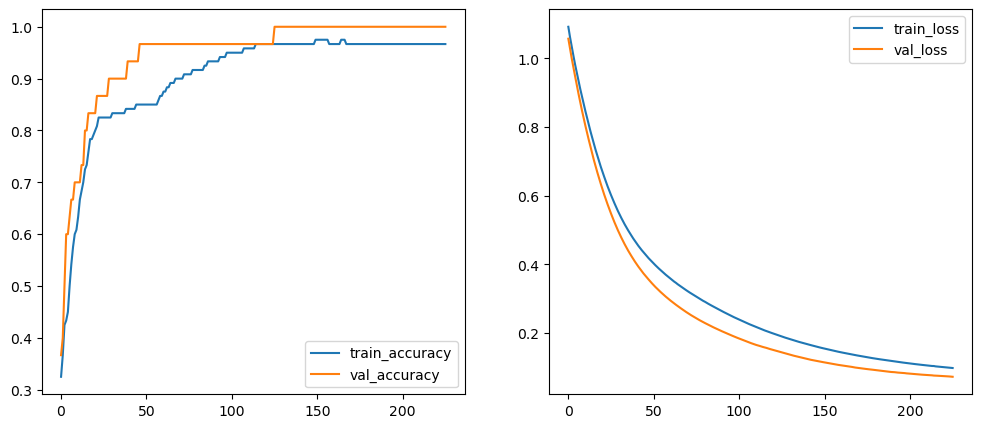

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()


In [58]:
y_pred = model.predict(x_test_scaled)
y_pred[:5]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.6046492e-02, 7.8072041e-01, 2.0323308e-01],
       [9.8422760e-01, 1.2211161e-02, 3.5612516e-03],
       [1.1621572e-05, 1.4444983e-02, 9.8554337e-01],
       [2.5111970e-02, 6.0810548e-01, 3.6678252e-01],
       [4.4389563e-03, 7.4435252e-01, 2.5120854e-01]], dtype=float32)

In [59]:
import numpy as np

# softmax는 값중 제일 큰게 정답
np.argmax(y_pred, axis=1), np.argmax(y_test, axis=1)

(array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]))